In [2]:
import pandas as pd

In [3]:
dataset=pd.read_csv("insurance_pre.csv")

In [4]:
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [5]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first='True')

In [6]:
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0
1334,18,31.920,0,2205.98080,0,0
1335,18,36.850,0,1629.83350,0,0
1336,21,25.800,0,2007.94500,0,0


In [7]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [8]:
independent=dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]

In [9]:
independent

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0
...,...,...,...,...,...
1333,50,30.970,3,1,0
1334,18,31.920,0,0,0
1335,18,36.850,0,0,0
1336,21,25.800,0,0,0


In [10]:
dependent=dataset[['charges']]

In [11]:
dependent

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30, random_state=0)

In [13]:
print(X_train.shape)
print(y_train.shape)

(936, 5)
(936, 1)


In [51]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='poisson',splitter='random')
regressor=regressor.fit(X_train,y_train)

In [52]:
regressor

,criterion,'poisson'
,splitter,'random'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.6568802573381397, 0.9772727272727273, 'x[4] <= 0.5\nfriedman_mse = 140986233.214\nsamples = 936\nvalue = 13232.916'),
 Text(0.4175289299214183, 0.9318181818181818, 'x[0] <= 42.5\nfriedman_mse = 37737689.841\nsamples = 746\nvalue = 8616.732'),
 Text(0.537204593629779, 0.9545454545454546, 'True  '),
 Text(0.2229475994945127, 0.8863636363636364, 'x[0] <= 26.5\nfriedman_mse = 22225839.786\nsamples = 407\nvalue = 5418.786'),
 Text(0.14611788739114875, 0.8409090909090909, 'x[2] <= 3.5\nfriedman_mse = 21407144.881\nsamples = 177\nvalue = 3657.79'),
 Text(0.10996212573064536, 0.7954545454545454, 'x[0] <= 22.5\nfriedman_mse = 19404317.899\nsamples = 172\nvalue = 3507.23'),
 Text(0.07066384349278301, 0.75, 'x[1] <= 29.957\nfriedman_mse = 17041016.514\nsamples = 120\nvalue = 3064.763'),
 Text(0.04503161159489443, 0.7045454545454546, 'x[2] <= 0.5\nfriedman_mse = 1756297.11\nsamples = 61\nvalue = 2251.492'),
 Text(0.026959322438267923, 0.6590909090909091, 'x[0] <= 19.5\nfriedman_mse = 12075

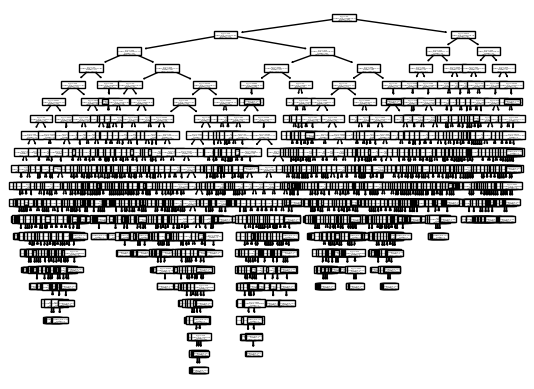

In [25]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)

In [26]:
plt.show()

In [53]:
y_pred=regressor.predict(X_test)

In [54]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)
r_score

0.7052811058705176